### LOADING AND SETUP

In [4]:
import fastf1
import os
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')

cache_dir = r'D:\PJT2\FastF1_demo\cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
fastf1.Cache.enable_cache(cache_dir)

### PULLING GP AND DRIVER DATA FOR TELEMETRY

In [5]:
session = fastf1.get_session(2024, 'Silverstone', 'R')
session.load()

driver_telemetry = session.laps.pick_driver('SAI').pick_fastest().get_telemetry()

core           INFO 	Loading data for British Grand Prix - Race [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

### PRE-PROCESSING FOR ANOMALY DETECTION

In [6]:
features = ['Speed', 'RPM', 'Throttle', 'nGear']
telemetry_data = driver_telemetry[features].copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(telemetry_data)

### REAL-TIME ANOMALY DETECTION

In [7]:
model = IsolationForest(contamination=0.01, random_state=42)
driver_telemetry['Anomaly_Score'] = model.fit_predict(scaled_data)

### DASHBOARD VISUALISATION

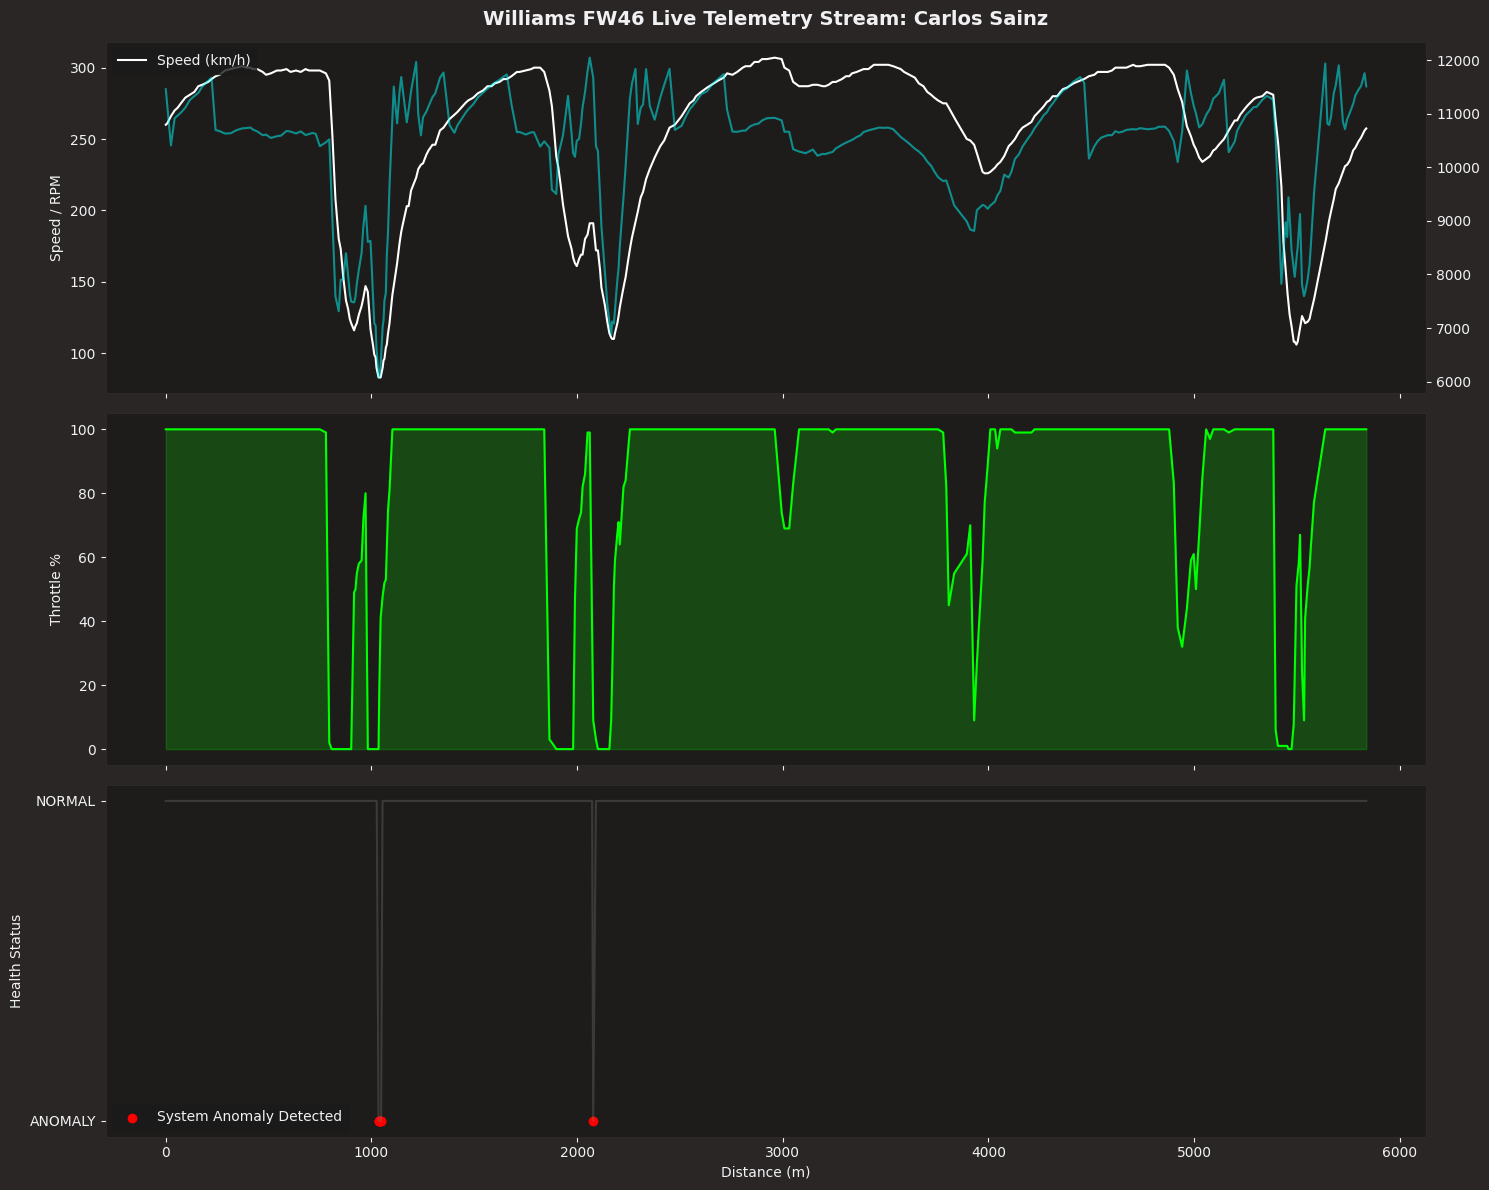

Paddock Demo Complete: Analyzed 675 telemetry point.


In [8]:
fig, ax = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Plot 1: Speed & RPM
ax[0].plot(driver_telemetry['Distance'], driver_telemetry['Speed'], color='white', label='Speed (km/h)')
ax[0].set_ylabel('Speed / RPM')
ax[0].set_title('Williams FW46 Live Telemetry Stream: Carlos Sainz', fontsize=14, fontweight='bold')
ax_rpm = ax[0].twinx()
ax_rpm.plot(driver_telemetry['Distance'], driver_telemetry['RPM'], color='cyan', alpha=0.5, label='RPM')
ax[0].legend(loc='upper left')

# Plot 2: Throttle Position
ax[1].plot(driver_telemetry['Distance'], driver_telemetry['Throttle'], color='lime', label='Throttle %')
ax[1].set_ylabel('Throttle %')
ax[1].fill_between(driver_telemetry['Distance'], driver_telemetry['Throttle'], color='lime', alpha=0.2)

# Plot 3: Anomaly Detection (The "Pit Wall" Warning)
anomalies = driver_telemetry[driver_telemetry['Anomaly_Score'] == -1]
ax[2].plot(driver_telemetry['Distance'], driver_telemetry['Anomaly_Score'], color='gray', alpha=0.3)
ax[2].scatter(anomalies['Distance'], anomalies['Anomaly_Score'], color='red', label='System Anomaly Detected')
ax[2].set_ylabel('Health Status')
ax[2].set_xlabel('Distance (m)')
ax[2].set_yticks([-1, 1])
ax[2].set_yticklabels(['ANOMALY', 'NORMAL'])
ax[2].legend()

plt.tight_layout()
plt.show()

print(f"Paddock Demo Complete: Analyzed {len(driver_telemetry)} telemetry point.")